# Treinamento dos Modelos — Soja

Neste notebook serão treinados diferentes modelos de visão computacional para classificação de doenças em folhas de soja.

1. Carregamento dos dados pré-processados;
2. Definição dos experimentos no MLflow;
3. Treinamento de um modelo baseline criado do zero;
4. Treinamento de modelos pré-treinados com transfer learning;
5. Comparação entre learning rate fixo e One Cycle Policy;
6. Avaliação com matrizes de confusão;
7. Comparação final dos experimentos.

In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
import torch
import mlflow
import mlflow.pytorch

import matplotlib.pyplot as plt
import seaborn as sns

from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
from sklearn.metrics import confusion_matrix

from src.dataset.soja_dataset import criar_dataloaders
from src.models.soja_models import get_model

from src.train import find_best_lr, run_training
from src.evaluate import get_predictions

In [0]:
EXPERIMENT_NAME = "/Shared/Soja_Doencas"

mlflow.set_experiment(EXPERIMENT_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Experimento:", EXPERIMENT_NAME)
print("Device:", device)

Experimento: /Shared/Soja_Doencas
Device: cpu


## 3. Carregamento dos dados

Nesta etapa carregamos os dados de soja já pré-processados e divididos em treino, validação e teste.

Os `DataLoaders` serão responsáveis por alimentar os modelos em batches durante o treinamento.

No Databricks Free Edition, utilizamos `num_workers = 0` para evitar problemas relacionados a multiprocessing.

In [0]:
train_loader, val_loader, test_loader = criar_dataloaders(
    batch_size=32,
    num_workers=0
)

classes = train_loader.dataset.classes
num_classes = len(classes)

print("Classes:", classes)
print("Número de classes:", num_classes)
print("Total treino:", len(train_loader.dataset))
print("Total validação:", len(val_loader.dataset))
print("Total teste:", len(test_loader.dataset))

Classes: ['Crestamento', 'Ferrugem', 'Mancha_Parda', 'Mosaico_Amarelo', 'Oidio', 'Podridao_Sul', 'Queima_Bacteriana', 'Septoriose', 'Sindrome_Morte_Subita', 'Soja_Saudavel', 'Virus_Mosaico']
Número de classes: 11
Total treino: 4100
Total validação: 865
Total teste: 877


## 4. Modelo criado do zero (Baseline)

Nesta seção utilizamos uma arquitetura de rede neural convolucional desenvolvida do zero (`CNN_Simples`).

O objetivo deste modelo é servir como **baseline**, ou seja:

- estabelecer um ponto de referência de desempenho;
- permitir comparação com modelos pré-treinados;
- entender a capacidade do modelo em aprender padrões diretamente dos dados, sem transfer learning.

Esse modelo será utilizado nos experimentos iniciais antes da aplicação de arquiteturas mais complexas.

### Learning Rate Finder — CNN Simples

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `CNN_Simples`.

O LR Finder funciona testando múltiplos valores de learning rate ao longo de um único ciclo de treinamento e observando o comportamento da função de perda.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis;
- Evitar valores muito baixos (treinamento lento);
- Evitar valores muito altos (divergência do modelo);
- Definir um valor inicial mais eficiente para o treinamento.

#### Configuração do experimento:

- Modelo: `cnn_simples`
- Estratégia: Treinamento do zero (sem transfer learning)
- Backbone congelado: Não aplicável, mas mantido como padrão
- Dataset: soja (dados já pré-processados e divididos)
- Registro: MLflow

O resultado será um gráfico que relaciona:

- Learning Rate vs Loss

A partir desse gráfico, será possível escolher um learning rate adequado para os próximos experimentos.

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR sugerido: 0.003944
LR suggestion: steepest gradient
Suggested LR: 3.94E-03


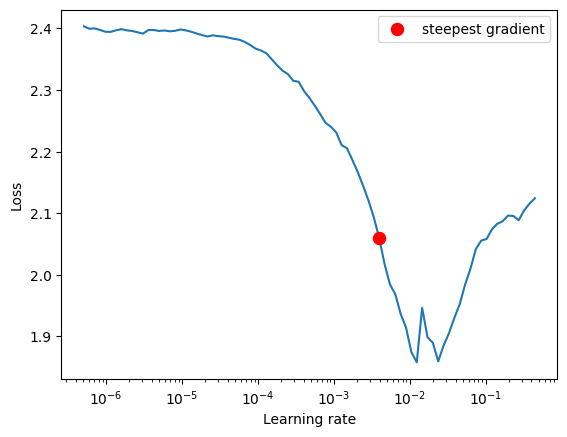

In [0]:
model_name = "simplecnn"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr)

    fig

### Treinamento — CNN Simples com Learning Rate fixo

Nesta etapa será realizado o treinamento da `CNN_Simples` utilizando um **learning rate fixo**, previamente determinado através do LR Finder.

#### Objetivo desta etapa:

- Avaliar o desempenho do modelo utilizando uma taxa de aprendizado constante;
- Servir como baseline para comparação com estratégias mais avançadas;
- Observar a estabilidade do treinamento ao longo das épocas.

#### Configuração do experimento:

- Modelo: `cnn_simples`
- Learning Rate: valor sugerido pelo LR Finder
- Épocas: 30
- Early stopping: Sim (`patience = 5`)
- One Cycle Policy: Não
- Dataset: soja
- Registro: MLflow

Durante o treinamento serão registradas no MLflow as métricas de loss e acurácia para treino e validação.

In [0]:
model_name = "simplecnn"
learning_rate = suggested_lr
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_cnn, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_cnn(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_cnn,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.5290 | Val Acc: 0.0786
Epoch 2/30 | Train Acc: 0.6473 | Val Acc: 0.9017
Epoch 3/30 | Train Acc: 0.6778 | Val Acc: 0.9179
Epoch 4/30 | Train Acc: 0.7059 | Val Acc: 0.9665
Epoch 5/30 | Train Acc: 0.6954 | Val Acc: 0.9723
Epoch 6/30 | Train Acc: 0.7276 | Val Acc: 0.9688
Epoch 7/30 | Train Acc: 0.7456 | Val Acc: 0.4855
Epoch 8/30 | Train Acc: 0.7461 | Val Acc: 0.9780
Epoch 9/30 | Train Acc: 0.7493 | Val Acc: 0.8139
Epoch 10/30 | Train Acc: 0.7666 | Val Acc: 0.9676
Epoch 11/30 | Train Acc: 0.7807 | Val Acc: 0.9873
Epoch 12/30 | Train Acc: 0.7841 | Val Acc: 0.9792
Epoch 13/30 | Train Acc: 0.7980 | Val Acc: 0.9769
Epoch 14/30 | Train Acc: 0.8090 | Val Acc: 0.9861
Epoch 15/30 | Train Acc: 0.8183 | Val Acc: 0.9815
Epoch 16/30 | Train Acc: 0.8151 | Val Acc: 0.9723
Early stopping acionado.


2026/05/17 01:17:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9c92b906-eef5.cloud.databricks.com/ml/experiments/331673162359779/models/m-4292c8ce370c4b3eac9641d1533132c5?o=1016405703992070


## Matriz de Confusão — CNN Simples (Learning Rate fixo)

Após o treinamento da `CNN_Simples` com learning rate fixo, realizamos a avaliação do modelo no conjunto de validação por meio da matriz de confusão.

Essa análise permite observar como o modelo está classificando cada classe individualmente, complementando métricas agregadas como acurácia e loss.

#### Objetivo desta etapa:

- Avaliar o poder de discriminação do modelo baseline;
- Identificar classes com maior dificuldade de classificação;
- Verificar possíveis confusões entre doenças visualmente semelhantes;
- Registrar a matriz de confusão como artefato no MLflow.

In [0]:
experiment_name = "/Shared/Soja_Doencas"
run_name = "simplecnn"

experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.mlflow.runName = '{run_name}'",
    order_by=["start_time DESC"],
    max_results=1
)

run_id_cnn = runs.iloc[0]["run_id"]

print("Run encontrada:", run_id_cnn)

Run encontrada: 308bd6be39fc416baccfa5719d4190fe


In [0]:
run_id_cnn = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_cnn):

    val_labels, val_preds = get_predictions(model_cnn, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_cnn_simples.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_cnn_simples.png")

## CNN Simples com One Cycle Policy

Nesta etapa será realizado o treinamento da `CNN_Simples` utilizando a estratégia de **One Cycle Policy**.

Diferente do treinamento com learning rate fixo, essa abordagem ajusta dinamicamente a taxa de aprendizado ao longo das épocas.

#### Objetivo desta etapa:

- Avaliar o desempenho da CNN com uma estratégia dinâmica de learning rate;
- Verificar se a One Cycle Policy melhora a convergência do modelo;
- Comparar os resultados com o treinamento utilizando learning rate fixo;
- Analisar se há melhora na generalização no conjunto de validação.

In [0]:
model_name = "simplecnn"
learning_rate = suggested_lr
epochs = 30
freeze_backbone = True
use_onecycle = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="simplecnn_1cycle"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_cnn_1cycle, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        use_onecycle=use_onecycle
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_cnn_1cycle(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_cnn_1cycle,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

Epoch 1/30 | Train Acc: 0.4268 | Val Acc: 0.0832


## Matriz de Confusão — CNN Simples (One Cycle Policy)

Após o treinamento da `CNN_Simples` utilizando One Cycle Policy, avaliamos o modelo no conjunto de validação por meio da matriz de confusão.

Essa etapa permite comparar o comportamento da CNN com e sem estratégia dinâmica de learning rate.

In [0]:
run_id_cnn_1cycle = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_cnn_1cycle):

    val_labels, val_preds = get_predictions(model_cnn_1cycle, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_cnn_simples_1cycle.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_cnn_simples_1cycle.png")

## 5. Modelo pré-treinado (Transfer Learning) — ResNet18

Nesta seção utilizamos a arquitetura `ResNet18`, um modelo pré-treinado no dataset ImageNet, amplamente utilizado em tarefas de visão computacional.

O objetivo deste modelo é aplicar **transfer learning**, ou seja:

- aproveitar padrões já aprendidos em grandes volumes de dados;
- reduzir o tempo de treinamento;
- melhorar a capacidade de generalização;
- obter melhor desempenho em comparação com modelos treinados do zero.

Neste experimento, utilizamos a estratégia de:

- **Backbone congelado (`freeze_backbone = True`)**

Isso significa que:

- as camadas convolucionais permanecem fixas;
- apenas a camada final de classificação é treinada;
- o modelo adapta o conhecimento prévio ao problema específico de classificação de doenças na soja.

### Learning Rate Finder — ResNet18

Nesta etapa utilizamos o **Learning Rate Finder (LR Finder)** para identificar uma taxa de aprendizado adequada para o treinamento da `ResNet18`.

#### Objetivo desta etapa:

- Encontrar um intervalo de learning rates estáveis para fine-tuning;
- Evitar valores muito baixos;
- Evitar valores muito altos que prejudiquem os pesos pré-treinados;
- Definir um learning rate inicial adequado para o treinamento da camada final.

#### Configuração do experimento:

- Modelo: `ResNet18`
- Estratégia: Transfer learning
- Backbone congelado: Sim (`freeze_backbone = True`)
- Dataset: soja
- Registro: MLflow

In [0]:
model_name = "resnet18"
freeze_backbone = True

mlflow.set_experiment("/Shared/Soja_Doencas")

with mlflow.start_run(run_name="resnet18_best_lr"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", num_classes)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("classes", classes)

    suggested_lr_resnet18, fig = find_best_lr(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        device=device,
        freeze_backbone=freeze_backbone
    )

    mlflow.log_param("suggested_lr", suggested_lr_resnet18)

    fig

### Treinamento — ResNet18 com Learning Rate fixo

Nesta etapa será realizado o treinamento da `ResNet18` utilizando um learning rate fixo, definido a partir do valor sugerido pelo LR Finder.

#### Configuração do experimento:

- Modelo: `ResNet18`
- Estratégia: Transfer learning
- Backbone congelado: Sim
- Épocas: 30
- Early stopping: Sim
- One Cycle Policy: Não
- Dataset: soja
- Registro: MLflow

In [0]:
model_name = "resnet18"
learning_rate = suggested_lr_resnet18
epochs = 30
freeze_backbone = True
patience = 5
use_onecycle = False

with mlflow.start_run(run_name="resnet18"):

    mlflow.log_param("model_name", model_name)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("freeze_backbone", freeze_backbone)
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("classes", classes)
    mlflow.log_param("patience", patience)
    mlflow.log_param("use_onecycle", use_onecycle)

    model_resnet18, history = run_training(
        model_name=model_name,
        num_classes=num_classes,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        freeze_backbone=freeze_backbone,
        device=device,
        patience=patience
    )

    for epoch in range(len(history["train_loss"])):
        mlflow.log_metric("train_loss", history["train_loss"][epoch], step=epoch)
        mlflow.log_metric("train_acc", history["train_acc"][epoch], step=epoch)
        mlflow.log_metric("val_loss", history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("val_acc", history["val_acc"][epoch], step=epoch)

    example_input, _ = next(iter(train_loader))

    with torch.no_grad():
        example_output = model_resnet18(example_input.to(device))

    signature = infer_signature(
        example_input.cpu().numpy(),
        example_output.cpu().numpy()
    )

    mlflow.pytorch.log_model(
        model_resnet18,
        "model",
        signature=signature,
        input_example=example_input[:1].cpu().numpy()
    )

## Matriz de Confusão — ResNet18 (Learning Rate fixo)

Após o treinamento da `ResNet18` com learning rate fixo, avaliamos o modelo no conjunto de validação utilizando a matriz de confusão.

Essa análise permite verificar se o transfer learning contribuiu para melhor discriminação entre as classes de soja.

In [0]:
run_id_resnet18 = mlflow.last_active_run().info.run_id

with mlflow.start_run(run_id=run_id_resnet18):

    val_labels, val_preds = get_predictions(model_resnet18, val_loader, device)

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão - Validação")

    plt.tight_layout()
    plt.savefig("figures/confusion_matrix_resnet18.png")
    plt.close()

    mlflow.log_artifact("figures/confusion_matrix_resnet18.png")